In [1]:
!pip install torch_geometric

import torch
import torch_geometric

print(f"PyTorch version: {torch.__version__}")
print(f"PyG version: {torch_geometric.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device set to: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.8 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
PyG version: 2.7.0
GPU available: True
Device set to: cuda


##Loading Dataset

In [2]:
from torch_geometric.datasets import FB15k_237


dataset = FB15k_237(root='./data/FB15k-237')

# The dataset object contains train, validation, and test splits.
# Let's look at the training graph (dataset[0])
data = dataset[0].to(device)

print(f"Dataset: {dataset.__class__.__name__}")
print(f"Number of Entities (Nodes): {data.num_nodes}")
# Infer the number of relation types from the edge_type tensor
num_relation_types = data.edge_type.max().item() + 1
print(f"Number of Relation Types (Edge Types): {num_relation_types}")
print(f"Total Triplets (Edges) in training: {data.num_edges}")

print("\n--- Graph Structure Tensors ---")
print(f"Edge Index shape: {data.edge_index.shape}")
print(f"Edge Type shape: {data.edge_type.shape}")


##Loading the test and validation datasets
# Load the Validation Set
val_dataset = FB15k_237(root='./data/FB15k-237', split='val')
val_data = val_dataset[0].to(device)

# Load the Test Set (For the very end)
test_dataset = FB15k_237(root='./data/FB15k-237', split='test')
test_data = test_dataset[0].to(device)

print("Train, Validation, and Test sets are all successfully loaded into memory!")

Processing...
Done!


Dataset: FB15k_237
Number of Entities (Nodes): 14541
Number of Relation Types (Edge Types): 237
Total Triplets (Edges) in training: 272115

--- Graph Structure Tensors ---
Edge Index shape: torch.Size([2, 272115])
Edge Type shape: torch.Size([272115])
Train, Validation, and Test sets are all successfully loaded into memory!


#Model-2 : CompGCN

##CompGCN Class

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing

# Custom Compconv class to implement message passing
class CompConv(MessagePassing):  ##as the model is not loaded in torch_geometric , we use it here directly
    def __init__(self, in_channels, out_channels, op="mult"): #change to sub /corr if required
        # Mean aggregation
        super().__init__(aggr="mean")
        self.op = op

        # Shared global node matrix
        self.W_node = nn.Linear(in_channels, out_channels, bias=False)

        # Shared global relation matrix
        self.W_rel = nn.Linear(in_channels, out_channels, bias=False)

    def forward(self, x, edge_index, edge_type, rel_emb):
        # 1. Look up the specific relation vector for every single edge
        edge_features = rel_emb[edge_type] # Shape: [num_edges, 128]
        x_updated = self.propagate(edge_index, x=x, edge_features=edge_features)

        ##this propagate function calls the message function below , where we compute the message

        x_updated = self.W_node(x_updated)
        rel_emb_updated = self.W_rel(rel_emb)

        return x_updated, rel_emb_updated

    def message(self, x_j, edge_features):
        # x_j is the Neighbor's 128-D vector
        # edge_features is the Relation's 128-D vector


        if self.op == "mult":
            return x_j * edge_features
        elif self.op == "sub":
            return x_j - edge_features
        else:
            raise ValueError("Operation must be 'mult' or 'sub'")

# CompGcn
class CompGCNLinkPredictor(torch.nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_channels, op="mult"):
        super().__init__()

        # Both nodes and relations get starting 128-D vectors
        self.node_emb = nn.Embedding(num_nodes, hidden_channels)
        self.rel_emb = nn.Embedding(num_relations, hidden_channels)

        # Using our custom CompConv!
        self.conv1 = CompConv(in_channels=hidden_channels, out_channels=hidden_channels, op=op)##added layer normalization
        self.norm1 = nn.LayerNorm(hidden_channels)

        self.conv2 = CompConv(in_channels=hidden_channels, out_channels=hidden_channels, op=op)
        self.norm2 = nn.LayerNorm(hidden_channels)


        self.drop = nn.Dropout(0.3)

    # def encode(self, edge_index, edge_type):
    #     x = self.node_emb.weight
    #     edge_attr = self.rel_emb.weight

    #     # Layer 1: Notice how it catches TWO outputs now!
    #     x, edge_attr = self.conv1(x, edge_index, edge_type, edge_attr)
    #     x = self.drop(F.relu(x))

    #     # Layer 2
    #     x, edge_attr = self.conv2(x, edge_index, edge_type, edge_attr)

    #     return x, edge_attr

    #new encode function with residual connections
    def encode(self, edge_index, edge_type):

        x_init = self.node_emb.weight
        edge_attr_init = self.rel_emb.weight

        # Layer 1
        x_updated, edge_attr_updated = self.conv1(x_init, edge_index, edge_type, edge_attr_init)
        x = self.norm1(x_updated) + x_init
        x = self.drop(F.relu(x))
        edge_attr = edge_attr_updated

        # Layer 2
        x_updated, edge_attr_updated = self.conv2(x, edge_index, edge_type, edge_attr)
        x = self.norm2(x_updated) + x
        edge_attr = edge_attr_updated

        return x, edge_attr

    #DistMULT scoring function
    # def decode(self, head_emb, rel_id, tail_emb, edge_attr):
    #     r_emb = edge_attr[rel_id]
    #     score = (head_emb * r_emb) * tail_emb
    #     return score.sum(dim=-1)

    ##TransE Decode function

    def decode(self, head_emb, rel_id, tail_emb, edge_attr):
        # 1. Get the smart relation vector
        r_emb = edge_attr[rel_id]
        distance = torch.norm(head_emb + r_emb - tail_emb, p=1, dim=-1)

        return -distance

print("Custom CompConv and CompGCN Architecture Loaded Successfully!")

Custom CompConv and CompGCN Architecture Loaded Successfully!


##Negetive sampler to generate negetive samples

In [4]:
def generate_negative_samples(edge_index, num_nodes, num_negatives=1):
    """
    Generates fake tail entities for every true edge.
    num_negatives: How many fake tails to generate per true edge.
    """
    num_edges = edge_index.size(1)

    # Extract the true heads and true tails
    heads = edge_index[0]

    # Randomly generate fake tails
    # torch.randint picks random numbers from 0 to (num_nodes - 1)
    fake_tails = torch.randint(0, num_nodes, (num_edges * num_negatives,), device=edge_index.device)

    # We repeat the heads to match the number of negative samples
    repeated_heads = heads.repeat_interleave(num_negatives)

    return repeated_heads, fake_tails


heads = data.edge_index[0, :5]
true_tails = data.edge_index[1, :5]
fake_heads, fake_tails = generate_negative_samples(data.edge_index[:, :5], data.num_nodes, num_negatives=5)

print("True Heads: ", heads)
print("True Tails: ", true_tails)
print("Fake Tails: ", fake_tails)

True Heads:  tensor([0, 2, 4, 6, 8], device='cuda:0')
True Tails:  tensor([1, 3, 5, 7, 9], device='cuda:0')
Fake Tails:  tensor([ 7017,  8544, 12298, 13613,  3349,   573,  9934,  9788, 14181,  9921,
         6064, 10287,  8199,  8188,  5201,  9542, 10114, 13348,  8136, 11163,
        12162,  4463, 10492, 10823,  9036], device='cuda:0')


#Training

In [ ]:
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch
import copy

# Hyperparameters
HIDDEN_DIM = 128
NUM_NEGATIVES = 10
BATCH_SIZE = 50000
EPOCHS = 1000
PATIENCE = 10


model = CompGCNLinkPredictor(
    num_nodes=data.num_nodes,
    num_relations=num_relation_types,
    hidden_channels=HIDDEN_DIM,
    op="sub" # Baseline operation
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

print(f"Initialized CompGCN (mult): {HIDDEN_DIM} Dims, {NUM_NEGATIVES} Negatives.")

# Batched training
def train_step_batched():
    model.train()
    total_loss = 0

    edge_indices = torch.arange(data.edge_index.size(1), device=device)
    dataloader = DataLoader(edge_indices, batch_size=BATCH_SIZE, shuffle=True)

    for batch_idx in dataloader:

        batch_idx = batch_idx.to(device)

        optimizer.zero_grad()

        node_emb, rel_emb = model.encode(data.edge_index, data.edge_type)

        heads = data.edge_index[0, batch_idx]
        rels = data.edge_type[batch_idx]
        true_tails = data.edge_index[1, batch_idx]

        neg_heads = heads.repeat(NUM_NEGATIVES)
        neg_rels = rels.repeat(NUM_NEGATIVES)
        fake_tails = torch.randint(0, data.num_nodes, (heads.size(0) * NUM_NEGATIVES,), device=device)

        pos_scores = model.decode(node_emb[heads], rels, node_emb[true_tails], rel_emb)
        neg_scores = model.decode(node_emb[neg_heads], neg_rels, node_emb[fake_tails], rel_emb)

        pos_scores_repeated = pos_scores.repeat(NUM_NEGATIVES)
        target = torch.ones_like(neg_scores)
        loss = F.margin_ranking_loss(pos_scores_repeated, neg_scores, target, margin=1.0)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)

# updated validation loss grader
def check_validation_mrr(model, train_graph, val_graph):
    model.eval()
    num_val_edges = val_graph.edge_index.size(1)
    mrr_sum = 0.0

    with torch.no_grad():

        node_emb, rel_emb = model.encode(train_graph.edge_index, train_graph.edge_type)

        for i in range(num_val_edges):
            h = val_graph.edge_index[0, i]
            r = val_graph.edge_type[i]
            true_t = val_graph.edge_index[1, i]

            all_possible_tails = torch.arange(train_graph.num_nodes, device=device)
            h_emb = node_emb[h].unsqueeze(0)
            t_embs = node_emb


            scores = model.decode(h_emb, r, t_embs, rel_emb)

            sorted_indices = torch.argsort(scores, descending=True)
            rank = (sorted_indices == true_t).nonzero(as_tuple=True)[0].item() + 1
            mrr_sum += 1.0 / rank

    return mrr_sum / num_val_edges


print("\nStarting CompGCN Training...")
patience_counter = 0
best_val_mrr = 0.0
best_model_weights = None

for epoch in range(1, EPOCHS + 1):
    loss = train_step_batched()

    if epoch % 25 == 0:
        print(f"Epoch {epoch:04d} | Training Loss: {loss:.4f} | Running Validation...")
        val_mrr = check_validation_mrr(model, data, val_data)
        print(f"          -> Validation MRR: {val_mrr:.4f}")

        if val_mrr > best_val_mrr:
            best_val_mrr = val_mrr
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print("          -> 🌟 New High Score! Weights saved.")
        else:
            patience_counter += 1
            print(f"          -> No improvement. Patience: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print("\n Early Stopping Triggered!")
            break

if best_model_weights is not None:
    model.load_state_dict(best_model_weights)
    print("\n Restored the best CompGCN weights from memory!")

Initialized CompGCN (mult): 128 Dims, 10 Negatives.

Starting CompGCN Training...
Epoch 0025 | Training Loss: 0.2112 | Running Validation...
          -> Validation MRR: 0.1020
          -> 🌟 New High Score! Weights saved.
Epoch 0050 | Training Loss: 0.1268 | Running Validation...
          -> Validation MRR: 0.1347
          -> 🌟 New High Score! Weights saved.
Epoch 0075 | Training Loss: 0.0977 | Running Validation...
          -> Validation MRR: 0.1593
          -> 🌟 New High Score! Weights saved.
Epoch 0100 | Training Loss: 0.0776 | Running Validation...
          -> Validation MRR: 0.1822
          -> 🌟 New High Score! Weights saved.
Epoch 0125 | Training Loss: 0.0634 | Running Validation...
          -> Validation MRR: 0.1936
          -> 🌟 New High Score! Weights saved.
Epoch 0150 | Training Loss: 0.0530 | Running Validation...
          -> Validation MRR: 0.2038
          -> 🌟 New High Score! Weights saved.
Epoch 0175 | Training Loss: 0.0451 | Running Validation...
          -> 

#Pykeen Pipeline (Same CompGCN model, from pykeen library)

In [ ]:
!pip install pykeen

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.5 MB/s eta 0:00:00


##Trying DistE + mult && Conve + corr(main trial)

In [ ]:
from pykeen.pipeline import pipeline

print("PyKEEN: CompGCN (corr) + DistMult")

result = pipeline(
    dataset='FB15k237',


    dataset_kwargs=dict(create_inverse_triples=True),

    model='CompGCN',

    model_kwargs=dict(
        embedding_dim=128,
        encoder_kwargs=dict(
            layer_kwargs=dict(
                composition='circularcorrelation',
            )
        ),

        interaction='DistMult',
    ),

    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.001),

    training_kwargs=dict(
        num_epochs=200,
        batch_size=8192,
    ),

    stopper='early',
    stopper_kwargs=dict(
        frequency=5,
        patience=10,
    ),

    device='cuda',
)

print("\n PYKEEN TEST RESULTS ")
print(result.metric_results.to_df())

INFO:pykeen.datasets.utils:Loading cached preprocessed dataset from file:///root/.data/pykeen/datasets/fb15k237/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/fb15k237/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/training
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/fb15k237/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/testing
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/fb15k237/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/validation
INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


PyKEEN: CompGCN (corr) + DistMult


INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=True for SingleCompGCNRepresentation()
INFO:pykeen.nn.representation:Inferred unique=True for SingleCompGCNRepresentation()
INFO:pykeen.stoppers.early_stopping:Inferred checkpoint path for best model weights: /root/.data/pykeen/checkpoints/best-model-weights-1b5689f7-c5b3-45bc-a5f6-7d94c8b095ff.pt
INFO:pykeen.triples.triples_factory:Creating inverse triples.


Training epochs on cuda:0:   0%|          | 0/20 [00:00<?, ?epoch/s]

INFO:pykeen.triples.triples_factory:Creating inverse triples.
INFO:pykeen.training.training_loop:Dropping last (incomplete) batch each epoch (1/66 (1.52%) batches).


...

Training batches on cuda:0:   0%|          | 0.00/66.0 [00:00<?, ?batch/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 7.36s seconds
INFO:pykeen.stoppers.early_stopping:New best result at epoch 20: 0.16658107953897067. Saved model weights to /root/.data/pykeen/checkpoints/best-model-weights-1b5689f7-c5b3-45bc-a5f6-7d94c8b095ff.pt
INFO:pykeen.training.training_loop:=> Saved checkpoint after having finished epoch 20.


Evaluating on cuda:0:   0%|          | 0.00/20.4k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 8.93s seconds



 PYKEEN TEST RESULTS 
     Side    Rank_type                         Metric     Value
0    head   optimistic  adjusted_arithmetic_mean_rank  0.119468
1    tail   optimistic  adjusted_arithmetic_mean_rank  0.084595
2    both   optimistic  adjusted_arithmetic_mean_rank  0.101790
3    head    realistic  adjusted_arithmetic_mean_rank  0.119468
4    tail    realistic  adjusted_arithmetic_mean_rank  0.084595
..    ...          ...                            ...       ...
220  tail    realistic             adjusted_hits_at_k  0.229921
221  both    realistic             adjusted_hits_at_k  0.171279
222  head  pessimistic             adjusted_hits_at_k  0.112635
223  tail  pessimistic             adjusted_hits_at_k  0.229921
224  both  pessimistic             adjusted_hits_at_k  0.171279

[225 rows x 4 columns]


##Pykeen Model Results

In [ ]:
mrr = result.metric_results.get_metric('inverse_harmonic_mean_rank')
hits_10 = result.metric_results.get_metric('hits_at_10')

print("\n" + "=" * 40)
print(" PYKEEN RESULTS ")
print(f"MRR:     {mrr:.4f}")
print(f"Hits@10: {hits_10 * 100:.2f}%")
print("=" * 40)


 PYKEEN RESULTS 
MRR:     0.2071
Hits@10: 37.05%


#Inference(CompGCN Custom Model)

In [ ]:
from tqdm.auto import tqdm
import torch

def evaluate_compgcn_test(model, train_data, test_data):
    model.eval()

    num_test_edges = test_data.edge_index.size(1)
    test_heads = test_data.edge_index[0]
    test_rels = test_data.edge_type
    test_tails = test_data.edge_index[1]

    mrr_sum = 0.0
    hits_at_10 = 0

    print(f"Starting TRUE Evaluation on {num_test_edges} unseen test edges...")

    with torch.no_grad():
        node_embeddings, rel_embeddings = model.encode(train_data.edge_index, train_data.edge_type)

        for i in tqdm(range(num_test_edges), desc="Evaluating Test Set"):
            h = test_heads[i]
            r = test_rels[i]
            true_t = test_tails[i]

            h_emb = node_embeddings[h].unsqueeze(0)
            t_embs = node_embeddings # All nodes


            scores = model.decode(h_emb, r, t_embs, rel_embeddings)

            sorted_indices = torch.argsort(scores, descending=True)
            rank = (sorted_indices == true_t).nonzero(as_tuple=True)[0].item() + 1

            mrr_sum += 1.0 / rank
            if rank <= 10:
                hits_at_10 += 1

    mrr = mrr_sum / num_test_edges
    h10 = (hits_at_10 / num_test_edges) * 100

    print("\n" + "=" * 40)
    print("COMP-GCN TEST SET RESULTS")
    print(f"Tested on: {num_test_edges} edges")
    print(f"MRR: {mrr:.4f}")
    print(f"Hits@10: {h10:.2f}%")
    print("=" * 40)


test_data = test_data.to(device)

evaluate_compgcn_test(model, data, test_data)

Starting TRUE Evaluation on 20466 unseen test edges...


Evaluating Test Set:   0%|          | 0/20466 [00:00<?, ?it/s]


COMP-GCN TEST SET RESULTS
Tested on: 20466 edges
MRR: 0.2652
Hits@10: 43.20%


#Downloading Best weights

In [ ]:
import torch
from google.colab import files


file_name = 'compgcn_model_exp_3.pt'

torch.save(model.state_dict(), file_name)
print(f"Model weights saved to {file_name}")


print("Downloading file to your computer...")
files.download(file_name)

Model weights saved to compgcn_model_exp_3.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Retreiving all stats of these models

## Custom Distmult

In [7]:
import torch
import pandas as pd
import numpy as np
from google.colab import files
from tqdm.auto import tqdm

path_DistMult = '/content/drive/MyDrive/compgcn_model_exp_3.pt' ##change path accordingly when using
actual_num_relations = int(data.edge_type.max()) + 1

print("\n Loading Baseline DistMult weights...")
model_DistMult = CompGCNLinkPredictor(data.num_nodes, actual_num_relations, 128, op="mult").to(device)
model_DistMult.load_state_dict(torch.load(path_DistMult, map_location=device))
model_DistMult.eval()

# Topology Prep
node_degrees = torch.bincount(data.edge_index.flatten(), minlength=data.num_nodes).cpu()
df_train = pd.DataFrame({'h': data.edge_index[0].cpu().numpy(), 'r': data.edge_type.cpu().numpy(), 't': data.edge_index[1].cpu().numpy()})
tph = df_train.groupby(['r', 'h'])['t'].nunique().groupby('r').mean()
hpt = df_train.groupby(['r', 't'])['h'].nunique().groupby('r').mean()
rel_types = {}
for r in df_train['r'].unique():
    t_ratio, h_ratio = tph.get(r, 1.0), hpt.get(r, 1.0)
    if h_ratio < 1.5 and t_ratio < 1.5: rel_types[r] = '1-to-1'
    elif h_ratio < 1.5 and t_ratio >= 1.5: rel_types[r] = '1-to-N'
    elif h_ratio >= 1.5 and t_ratio < 1.5: rel_types[r] = 'N-to-1'
    else: rel_types[r] = 'N-to-N'

# Evaluation
ranks = {'Global': [], 'Rare (<=10)': [], 'Hub (>=100)': [], '1-to-1': [], '1-to-N': [], 'N-to-1': [], 'N-to-N': []}
with torch.no_grad():
    node_embs, rel_embs = model_DistMult.encode(data.edge_index, data.edge_type)
    for i in tqdm(range(test_data.edge_index.size(1)), desc="Testing DistMult"):
        h, r, true_t = test_data.edge_index[0][i], test_data.edge_type[i], test_data.edge_index[1][i].item()
        scores = model_DistMult.decode(node_embs[h].unsqueeze(0), r, node_embs, rel_embs)
        rank = (torch.argsort(scores.squeeze(), descending=True) == true_t).nonzero(as_tuple=True)[0].item() + 1

        deg = node_degrees[true_t].item()
        rtype = rel_types.get(r.item(), 'N-to-N')

        ranks['Global'].append(rank)
        ranks[rtype].append(rank)
        if deg <= 10: ranks['Rare (<=10)'].append(rank)
        if deg >= 100: ranks['Hub (>=100)'].append(rank)


def get_metrics(r_list):
    a = np.array(r_list)
    if len(a) == 0: return 0.0, 0.0, 0.0, 0.0, 0
    return round(np.mean(1.0/a), 4), round(np.mean(a<=1)*100, 2), round(np.mean(a<=3)*100, 2), round(np.mean(a<=10)*100, 2), len(a)

report = []
for cat in ['Global', 'Rare (<=10)', 'Hub (>=100)', '1-to-1', '1-to-N', 'N-to-1', 'N-to-N']:
    m, h1, h3, h10, c = get_metrics(ranks[cat])
    report.append(['Baseline DistMult', cat, c, m, h1, h3, h10])

df_report = pd.DataFrame(report, columns=['Model', 'Category', 'Test_Sample_Size', 'MRR', 'Hits@1(%)', 'Hits@3(%)', 'Hits@10(%)'])
print("\n" + df_report.to_string(index=False))
df_report.to_csv('baseline_distmult_diagnostics.csv', index=False)
files.download('baseline_distmult_diagnostics.csv')


 Loading Baseline DistMult weights...


Testing DistMult:   0%|          | 0/20466 [00:00<?, ?it/s]


            Model    Category  Test_Sample_Size    MRR  Hits@1(%)  Hits@3(%)  Hits@10(%)
Baseline DistMult      Global             20466 0.2667      18.23      28.69       43.82
Baseline DistMult Rare (<=10)               768 0.0805       4.69       7.68       14.19
Baseline DistMult Hub (>=100)              9682 0.4639      34.46      50.71       71.31
Baseline DistMult      1-to-1               192 0.3852      32.81      40.62       50.00
Baseline DistMult      1-to-N              1293 0.0105       0.23       0.70        1.78
Baseline DistMult      N-to-1              4508 0.6721      57.63      73.94       83.67
Baseline DistMult      N-to-N             14473 0.1618       7.37      16.94       35.08


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Custom Transe

In [9]:

import torch
import pandas as pd
import numpy as np
from google.colab import files
from tqdm.auto import tqdm

path_TransE = '/content/drive/MyDrive/compgcn_model_exp_4_transE.pt'
actual_num_relations = int(data.edge_type.max()) + 1

print("\n Loading Baseline TransE weights...")
model_TransE = CompGCNLinkPredictor(data.num_nodes, actual_num_relations, 128, op="sub").to(device)
model_TransE.load_state_dict(torch.load(path_TransE, map_location=device))
model_TransE.eval()

# Topology Prep
node_degrees = torch.bincount(data.edge_index.flatten(), minlength=data.num_nodes).cpu()
df_train = pd.DataFrame({'h': data.edge_index[0].cpu().numpy(), 'r': data.edge_type.cpu().numpy(), 't': data.edge_index[1].cpu().numpy()})
tph = df_train.groupby(['r', 'h'])['t'].nunique().groupby('r').mean()
hpt = df_train.groupby(['r', 't'])['h'].nunique().groupby('r').mean()
rel_types = {}
for r in df_train['r'].unique():
    t_ratio, h_ratio = tph.get(r, 1.0), hpt.get(r, 1.0)
    if h_ratio < 1.5 and t_ratio < 1.5: rel_types[r] = '1-to-1'
    elif h_ratio < 1.5 and t_ratio >= 1.5: rel_types[r] = '1-to-N'
    elif h_ratio >= 1.5 and t_ratio < 1.5: rel_types[r] = 'N-to-1'
    else: rel_types[r] = 'N-to-N'

# Evaluation
ranks = {'Global': [], 'Rare (<=10)': [], 'Hub (>=100)': [], '1-to-1': [], '1-to-N': [], 'N-to-1': [], 'N-to-N': []}
with torch.no_grad():
    node_embs, rel_embs = model_TransE.encode(data.edge_index, data.edge_type)
    for i in tqdm(range(test_data.edge_index.size(1)), desc="Testing TransE"):
        h, r, true_t = test_data.edge_index[0][i], test_data.edge_type[i], test_data.edge_index[1][i].item()
        scores = model_TransE.decode(node_embs[h].unsqueeze(0), r, node_embs, rel_embs)
        rank = (torch.argsort(scores.squeeze(), descending=True) == true_t).nonzero(as_tuple=True)[0].item() + 1

        deg = node_degrees[true_t].item()
        rtype = rel_types.get(r.item(), 'N-to-N')

        ranks['Global'].append(rank)
        ranks[rtype].append(rank)
        if deg <= 10: ranks['Rare (<=10)'].append(rank)
        if deg >= 100: ranks['Hub (>=100)'].append(rank)


def get_metrics(r_list):
    a = np.array(r_list)
    if len(a) == 0: return 0.0, 0.0, 0.0, 0.0, 0
    return round(np.mean(1.0/a), 4), round(np.mean(a<=1)*100, 2), round(np.mean(a<=3)*100, 2), round(np.mean(a<=10)*100, 2), len(a)

report = []
for cat in ['Global', 'Rare (<=10)', 'Hub (>=100)', '1-to-1', '1-to-N', 'N-to-1', 'N-to-N']:
    m, h1, h3, h10, c = get_metrics(ranks[cat])
    report.append(['Baseline TransE', cat, c, m, h1, h3, h10])

df_report = pd.DataFrame(report, columns=['Model', 'Category', 'Test_Sample_Size', 'MRR', 'Hits@1(%)', 'Hits@3(%)', 'Hits@10(%)'])
print("\n" + df_report.to_string(index=False))
df_report.to_csv('baseline_transe_diagnostics.csv', index=False)
files.download('baseline_transe_diagnostics.csv')


 Loading Baseline TransE weights...


Testing TransE:   0%|          | 0/20466 [00:00<?, ?it/s]


          Model    Category  Test_Sample_Size    MRR  Hits@1(%)  Hits@3(%)  Hits@10(%)
Baseline TransE      Global             20466 0.2652      18.49      28.21       43.20
Baseline TransE Rare (<=10)               768 0.0883       5.60       8.07       14.71
Baseline TransE Hub (>=100)              9682 0.4627      34.82      50.26       70.87
Baseline TransE      1-to-1               192 0.3834      33.33      40.10       46.88
Baseline TransE      1-to-N              1293 0.0076       0.08       0.39        1.08
Baseline TransE      N-to-1              4508 0.6713      58.61      72.03       82.79
Baseline TransE      N-to-N             14473 0.1602       7.44      16.89       34.59


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## PYkeen Corr + Distmul stats


In [ ]:
import torch
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from google.colab import files
from pykeen.datasets import FB15k237
from pykeen.models import CompGCN



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


print("[1/4] Loading PyKEEN FB15k-237 Dataset...")
dataset = FB15k237(create_inverse_triples=True)
train_triples = dataset.training.mapped_triples.cpu()
test_triples = dataset.testing.mapped_triples.cpu()

# Loading weights back to class
print("[2/4] Rebuilding PyKEEN CompGCN (corr + DistMult)...")
path_pykeen = '/content/drive/MyDrive/pykeen_corr_distmult.pt'

model_pykeen = CompGCN(
    triples_factory=dataset.training,
    embedding_dim=128,
    encoder_kwargs=dict(layer_kwargs=dict(composition='circularcorrelation')),
    interaction='DistMult'
).to(device)

model_pykeen.load_state_dict(torch.load(path_pykeen, map_location=device))
model_pykeen.eval()

# Topology prep
print("[3/4] Analyzing PyKEEN Graph Structure...")
# A. Topology (Degrees)
node_degrees = torch.bincount(train_triples[:, 0], minlength=dataset.training.num_entities) + \
               torch.bincount(train_triples[:, 2], minlength=dataset.training.num_entities)

# Multiplicity (Relation Types)
df_train = pd.DataFrame({
    'h': train_triples[:, 0].numpy(),
    'r': train_triples[:, 1].numpy(),
    't': train_triples[:, 2].numpy()
})
tph = df_train.groupby(['r', 'h'])['t'].nunique().groupby('r').mean()
hpt = df_train.groupby(['r', 't'])['h'].nunique().groupby('r').mean()

relation_types = {}
for r in df_train['r'].unique():
    t_ratio, h_ratio = tph.get(r, 1.0), hpt.get(r, 1.0)
    if h_ratio < 1.5 and t_ratio < 1.5: relation_types[r] = '1-to-1'
    elif h_ratio < 1.5 and t_ratio >= 1.5: relation_types[r] = '1-to-N'
    elif h_ratio >= 1.5 and t_ratio < 1.5: relation_types[r] = 'N-to-1'
    else: relation_types[r] = 'N-to-N'


print("[4/4] Grading predictions...")
ranks_pykeen = {'Global': [], 'Rare (<=10)': [], 'Hub (>=100)': [], '1-to-1': [], '1-to-N': [], 'N-to-1': [], 'N-to-N': []}

with torch.no_grad():
    for i in tqdm(range(len(test_triples)), desc="Testing PyKEEN Edges"):
        h, r, true_t = test_triples[i]
        h_idx, r_idx, true_t_idx = h.item(), r.item(), true_t.item()

        degree = node_degrees[true_t_idx].item()
        rel_type = relation_types.get(r_idx, 'N-to-N')

        # PyKEEN native prediction formatting
        hr_batch = torch.tensor([[h_idx, r_idx]], device=device)
        scores = model_pykeen.predict_t(hr_batch).squeeze(0) # Get scores for all tails

        rank = (torch.argsort(scores, descending=True) == true_t_idx).nonzero(as_tuple=True)[0].item() + 1

        # Assign to buckets
        ranks_pykeen['Global'].append(rank)
        if degree <= 10: ranks_pykeen['Rare (<=10)'].append(rank)
        elif degree >= 100: ranks_pykeen['Hub (>=100)'].append(rank)
        ranks_pykeen[rel_type].append(rank)

# Format to Dataframe
def get_metrics(rank_list):
    arr = np.array(rank_list)
    if len(arr) == 0: return 0.0, 0.0, 0.0, 0.0, 0
    mrr = np.mean(1.0 / arr)
    h1 = np.mean(arr <= 1) * 100; h3 = np.mean(arr <= 3) * 100; h10 = np.mean(arr <= 10) * 100
    return round(mrr, 4), round(h1, 2), round(h3, 2), round(h10, 2), len(arr)

report_data = []
categories = ['Global', 'Rare (<=10)', 'Hub (>=100)', '1-to-1', '1-to-N', 'N-to-1', 'N-to-N']
for cat in categories:
    mrr, h1, h3, h10, count = get_metrics(ranks_pykeen[cat])
    report_data.append(['PyKEEN (corr+DistMult)', cat, count, mrr, h1, h3, h10])

df_report = pd.DataFrame(report_data, columns=['Model', 'Category', 'Test_Sample_Size', 'MRR', 'Hits@1(%)', 'Hits@3(%)', 'Hits@10(%)'])

print("\n" + "="*80)
print(df_report.to_string(index=False))
print("="*80 + "\n")

file_name = 'pykeen_diagnostics.csv'
df_report.to_csv(file_name, index=False)
files.download(file_name)

INFO:pykeen.utils:Using opt_einsum
INFO:pykeen.datasets.base:downloading data from https://download.microsoft.com/download/8/7/0/8700516A-AB3D-4850-B4BB-805C515AECE1/FB15K-237.2.zip to /root/.data/pykeen/datasets/fb15k237/FB15K-237.2.zip


[1/4] Loading PyKEEN FB15k-237 Dataset...


INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=True for SingleCompGCNRepresentation()
INFO:pykeen.nn.representation:Inferred unique=True for SingleCompGCNRepresentation()


[2/4] Rebuilding PyKEEN CompGCN (corr + DistMult)...
[3/4] Analyzing PyKEEN Graph Structure...
[4/4] Grading predictions...


Testing PyKEEN Edges:   0%|          | 0/20438 [00:00<?, ?it/s]


                 Model    Category  Test_Sample_Size    MRR  Hits@1(%)  Hits@3(%)  Hits@10(%)
PyKEEN (corr+DistMult)      Global             20438 0.1945      11.33      20.72       36.24
PyKEEN (corr+DistMult) Rare (<=10)               761 0.0545       3.42       5.26        8.41
PyKEEN (corr+DistMult) Hub (>=100)              9667 0.3410      21.42      37.75       61.03
PyKEEN (corr+DistMult)      1-to-1               192 0.3372      28.12      35.94       43.75
PyKEEN (corr+DistMult)      1-to-N              1290 0.0085       0.16       0.31        1.63
PyKEEN (corr+DistMult)      N-to-1              4490 0.4573      35.03      51.49       65.90
PyKEEN (corr+DistMult)      N-to-N             14466 0.1276       4.75      12.78       30.02



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Analysis-1: TransE VS Distmult performance by Graph topology

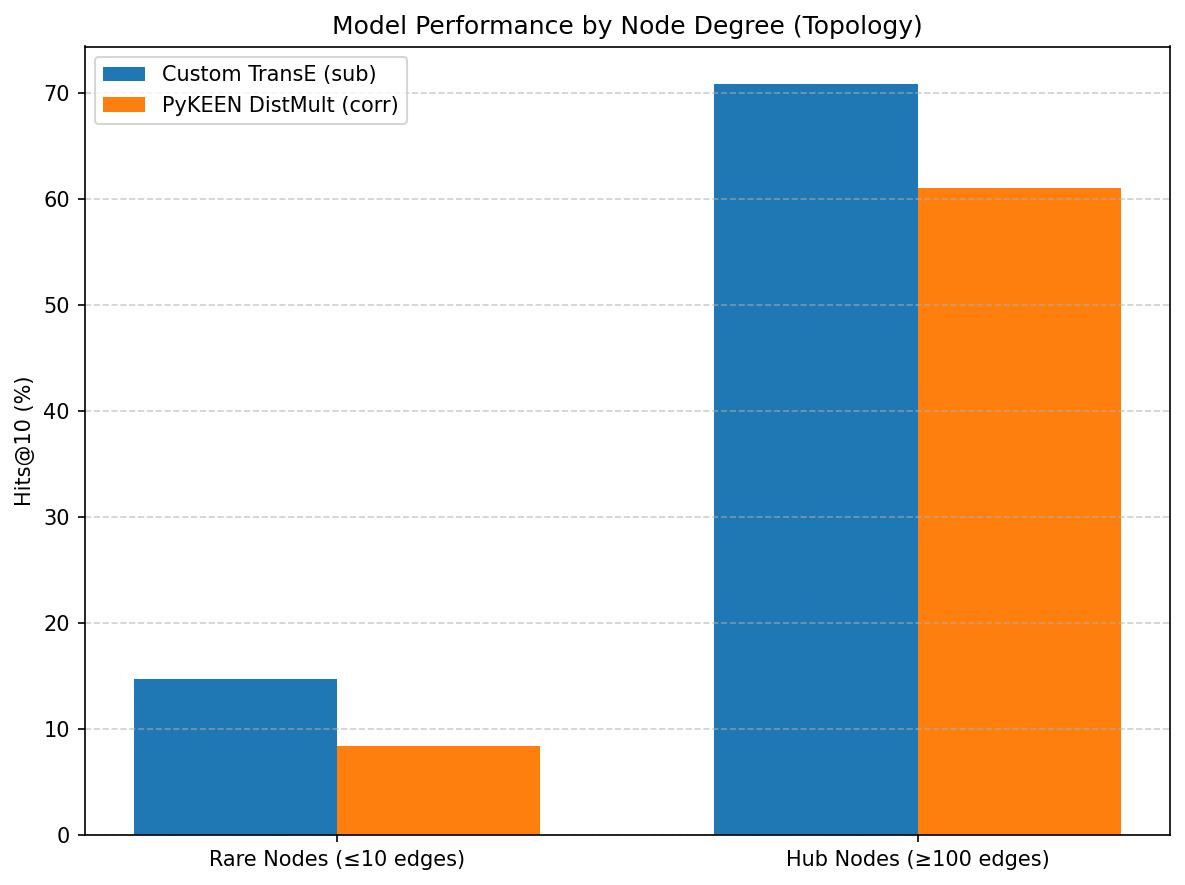

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

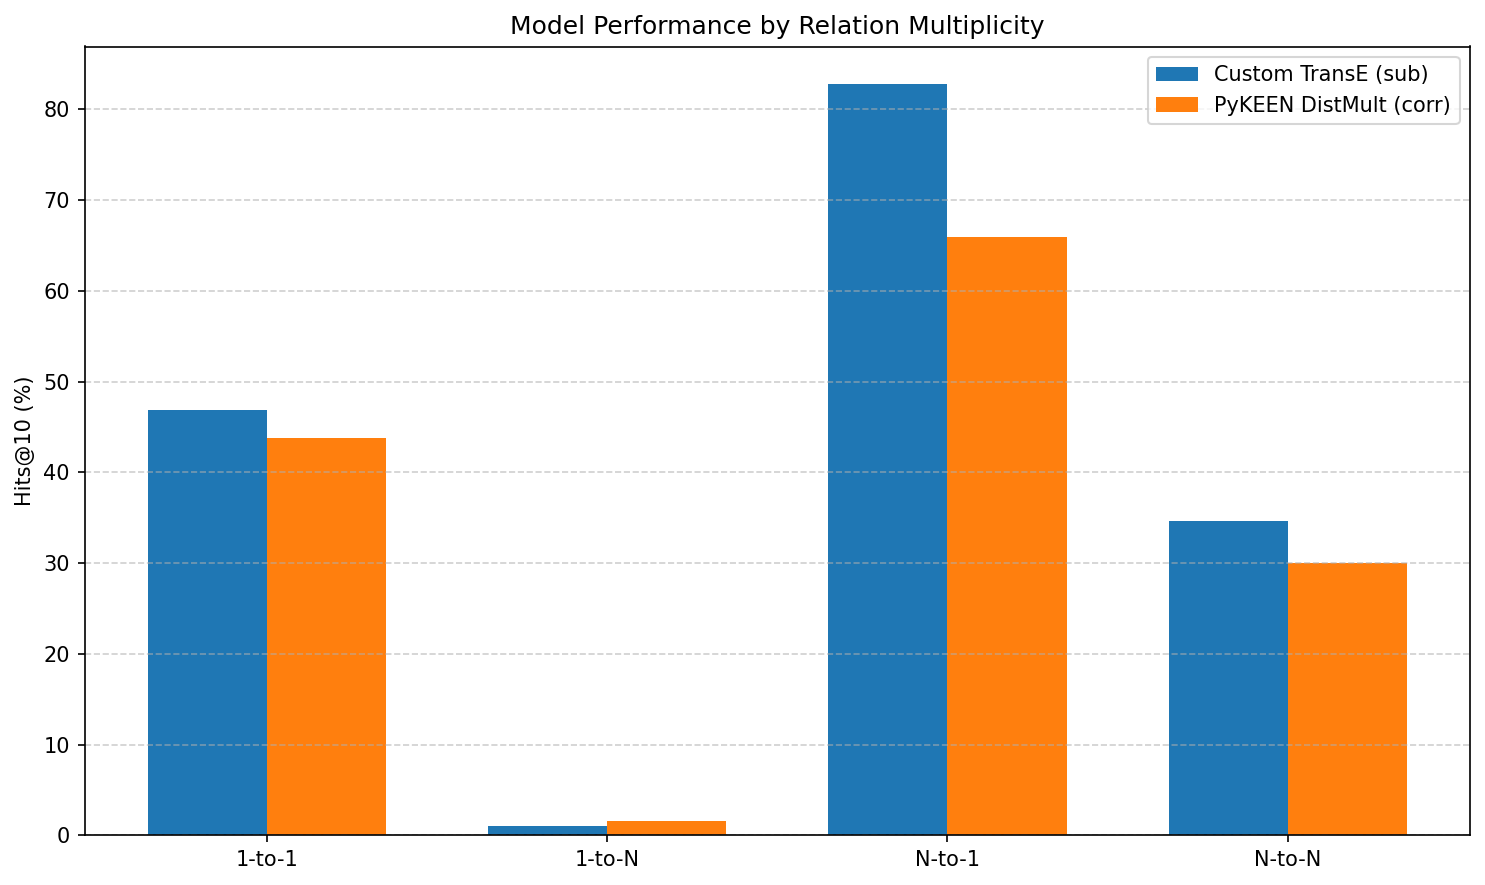

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


# 1. Load the CSVs you already created
try:
    df_master = pd.read_csv('/content/drive/MyDrive/master_model_diagnostics.csv')
    df_pykeen = pd.read_csv('/content/drive/MyDrive/pykeen_diagnostics.csv')
except FileNotFoundError:
    print("ERROR: Could not find the CSV files. Make sure they are in your Colab files!")
    raise

# 2. Extract Champion Data
df_transe = df_master[df_master['Model'] == 'TransE'].set_index('Category')
df_pyk = df_pykeen.set_index('Category') # PyKEEN only has one model in its CSV

# Function to safely get Hits@10
def get_scores(df, categories):
    return [df.loc[cat, 'Hits@10(%)'] if cat in df.index else 0 for cat in categories]


cats_topology = ['Rare (<=10)', 'Hub (>=100)']
scores_transe_top = get_scores(df_transe, cats_topology)
scores_pykeen_top = get_scores(df_pyk, cats_topology)

x_top = np.arange(len(cats_topology))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
ax.bar(x_top - width/2, scores_transe_top, width, label='Custom TransE (sub)', color='#1f77b4')
ax.bar(x_top + width/2, scores_pykeen_top, width, label='PyKEEN DistMult (corr)', color='#ff7f0e')

ax.set_ylabel('Hits@10 (%)')
ax.set_title('Model Performance by Node Degree (Topology)')
ax.set_xticks(x_top)
ax.set_xticklabels(['Rare Nodes (≤10 edges)', 'Hub Nodes (≥100 edges)'])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
file_1 = 'chart_topology_comparison.png'
plt.savefig(file_1)
plt.show()
files.download(file_1)


cats_mult = ['1-to-1', '1-to-N', 'N-to-1', 'N-to-N']
scores_transe_mult = get_scores(df_transe, cats_mult)
scores_pykeen_mult = get_scores(df_pyk, cats_mult)

x_mult = np.arange(len(cats_mult))

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.bar(x_mult - width/2, scores_transe_mult, width, label='Custom TransE (sub)', color='#1f77b4')
ax.bar(x_mult + width/2, scores_pykeen_mult, width, label='PyKEEN DistMult (corr)', color='#ff7f0e')

ax.set_ylabel('Hits@10 (%)')
ax.set_title('Model Performance by Relation Multiplicity')
ax.set_xticks(x_mult)
ax.set_xticklabels(cats_mult)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
file_2 = 'chart_multiplicity_comparison.png'
plt.savefig(file_2)
plt.show()
files.download(file_2)


#Model Explainablity (Easy Vs Hard Relations)

In [ ]:

import torch
import pandas as pd
from collections import defaultdict
from tqdm.auto import tqdm
from google.colab import files

print("🔍 Starting TransE Relation Explainability Analysis...")

# TransE + compgcn(sub)
path_B = '/content/drive/MyDrive/compgcn_model_exp_4_transE.pt'
actual_num_relations = int(data.edge_type.max()) + 1

champion_model = CompGCNLinkPredictor(
    num_nodes=data.num_nodes,
    num_relations=actual_num_relations,
    hidden_channels=128,
    op="sub"
).to(device)

champion_model.load_state_dict(torch.load(path_B, map_location=device))
champion_model.eval()


rel_mrr_sum = defaultdict(float)
rel_h10_sum = defaultdict(float)
rel_counts = defaultdict(int)

num_test_edges = test_data.edge_index.size(1)

with torch.no_grad():

    node_embeddings, rel_embeddings = champion_model.encode(data.edge_index, data.edge_type)

    for i in tqdm(range(num_test_edges), desc="Grading Specific Relations"):
        h = test_data.edge_index[0, i]
        r = test_data.edge_type[i].item()
        true_t = test_data.edge_index[1, i]

        # We need r as a tensor for the decode function
        r_tensor = torch.tensor([r], device=device)

        h_emb = node_embeddings[h].unsqueeze(0)
        t_embs = node_embeddings # All nodes

        # Decode using the CompGCN architecture
        scores = champion_model.decode(h_emb, r_tensor, t_embs, rel_embeddings)

        sorted_indices = torch.argsort(scores.squeeze(), descending=True)
        rank = (sorted_indices == true_t).nonzero(as_tuple=True)[0].item() + 1

        rel_mrr_sum[r] += 1.0 / rank
        rel_counts[r] += 1
        if rank <= 10:
            rel_h10_sum[r] += 1

# Results
results = []
for r in rel_counts:
    # Only considering relations that appeared at least 25 times to avoid statistical flukes
    if rel_counts[r] >= 25:
        results.append({
            'Relation_ID': r,
            'Test_Count': rel_counts[r],
            'MRR': round(rel_mrr_sum[r] / rel_counts[r], 4),
            'Hits@10 (%)': round((rel_h10_sum[r] / rel_counts[r]) * 100, 2)
        })

df_explain = pd.DataFrame(results).sort_values(by='Hits@10 (%)', ascending=False)

print("\n" + "="*50)
print("TOP 5 EASIEST RELATIONS (Model excels here)")
print("="*50)
print(df_explain.head().to_string(index=False))

print("\n" + "="*50)
print("TOP 5 HARDEST RELATIONS (Model performs bad here)")
print("="*50)
print(df_explain.tail().to_string(index=False))

csv_filename = "transe_relation_explainability.csv"
df_explain.to_csv(csv_filename, index=False)
files.download(csv_filename)

🔍 Starting TransE Relation Explainability Analysis...


Grading Specific Relations:   0%|          | 0/20466 [00:00<?, ?it/s]


TOP 5 EASIEST RELATIONS (Model excels here)
 Relation_ID  Test_Count    MRR  Hits@10 (%)
          33          46 0.9855        100.0
         118          50 0.9900        100.0
          43         436 0.8819        100.0
          85         346 0.9234        100.0
          11         158 0.9598        100.0

TOP 5 HARDEST RELATIONS (Model performs bad here)
 Relation_ID  Test_Count    MRR  Hits@10 (%)
         126          27 0.0026          0.0
         161          53 0.0013          0.0
          87          46 0.0017          0.0
         140          34 0.0084          0.0
         158          26 0.0166          0.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#TSNE- TransE

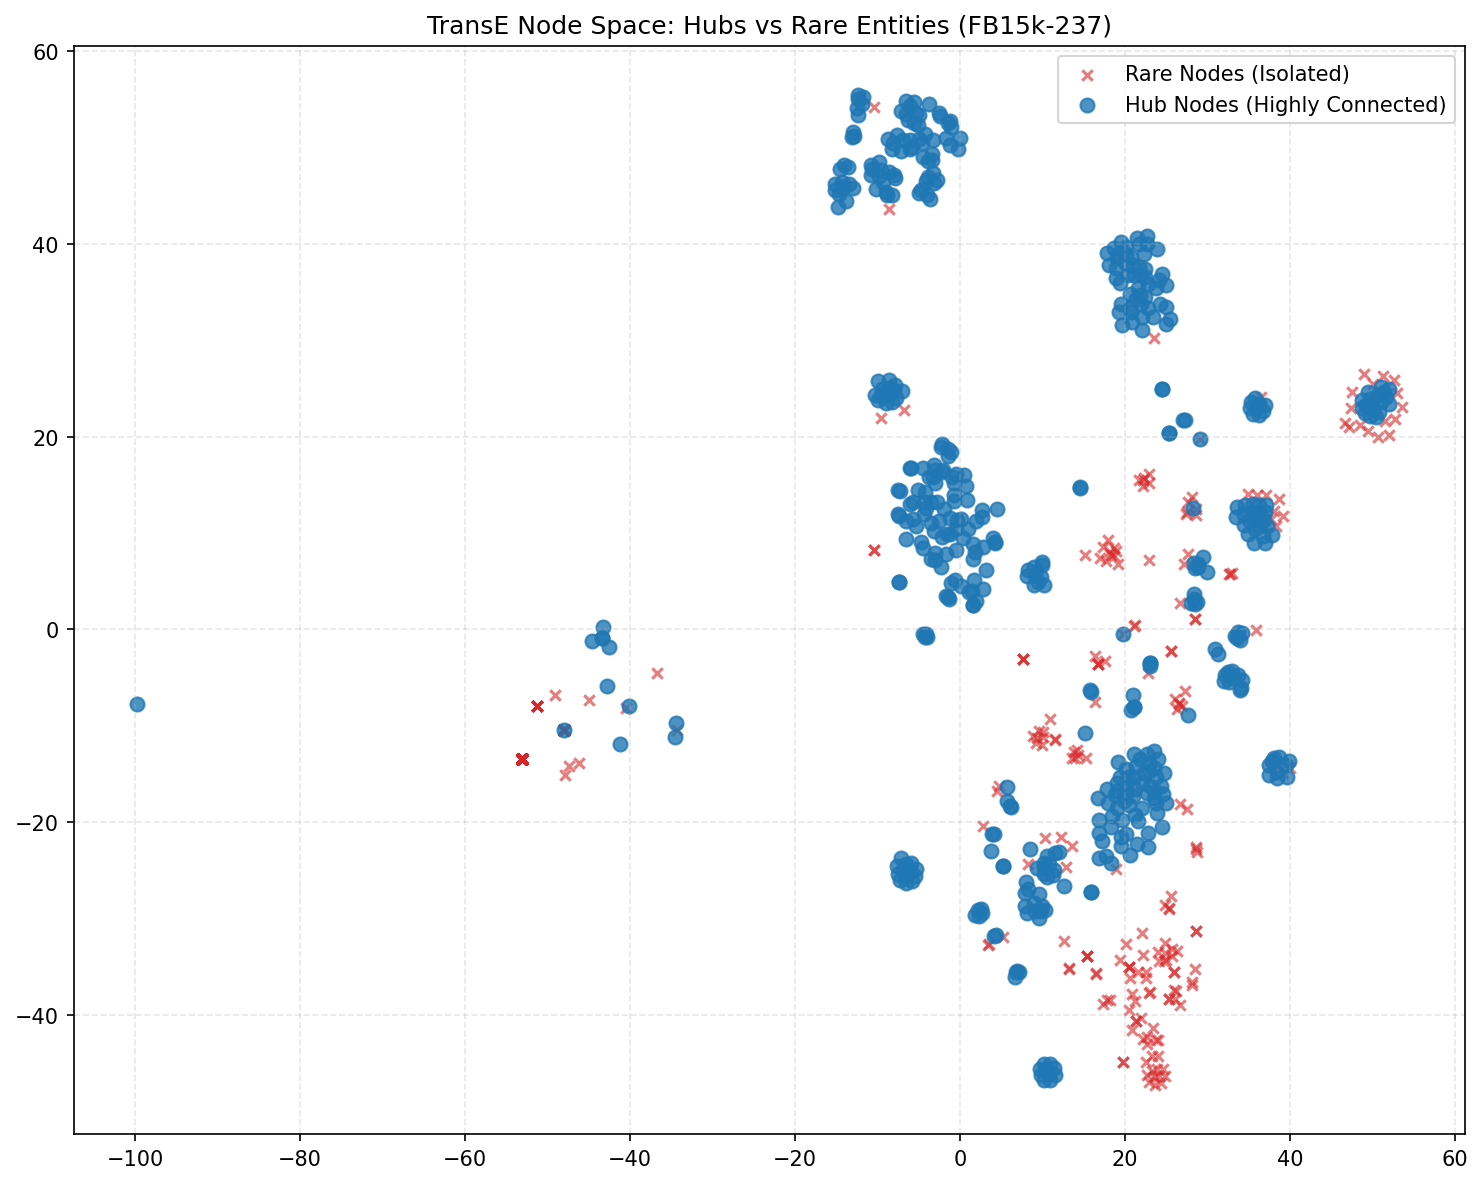

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

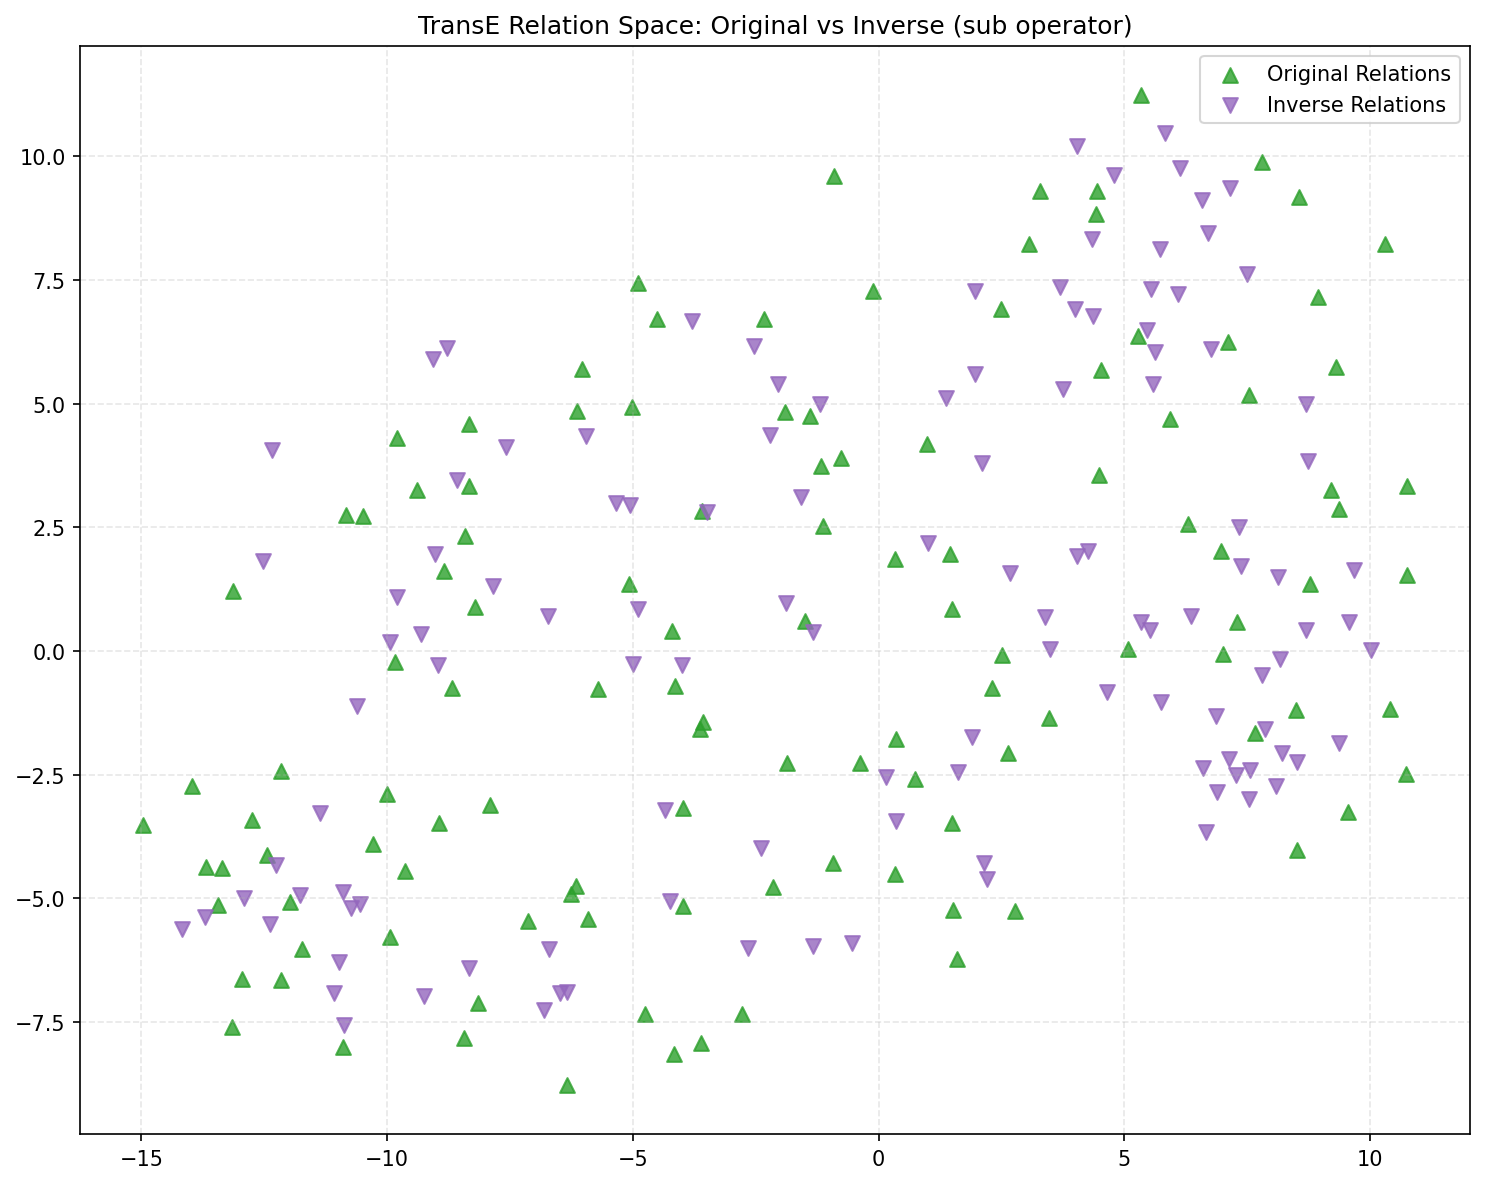

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from google.colab import files



path_B = '/content/drive/MyDrive/compgcn_model_exp_4_transE.pt'
actual_num_relations = int(data.edge_type.max()) + 1

model_transe = CompGCNLinkPredictor(
    num_nodes=data.num_nodes,
    num_relations=actual_num_relations,
    hidden_channels=128,
    op="sub"
).to(device)

model_transe.load_state_dict(torch.load(path_B, map_location=device))
model_transe.eval()

with torch.no_grad():
    node_embs, rel_embs = model_transe.encode(data.edge_index, data.edge_type)
    node_embs_np = node_embs.cpu().numpy()
    rel_embs_np = rel_embs.cpu().numpy()


node_degrees = torch.bincount(data.edge_index.flatten(), minlength=data.num_nodes).cpu()

hub_ids = torch.argsort(node_degrees, descending=True)[:500].numpy()
rare_ids = torch.argsort(node_degrees, descending=False)[:500].numpy()

selected_node_embs = node_embs_np[np.concatenate([hub_ids, rare_ids])]
node_embs_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(selected_node_embs)

hubs_2d = node_embs_2d[:500]
rares_2d = node_embs_2d[500:]

plt.figure(figsize=(10, 8), dpi=150)
plt.scatter(rares_2d[:, 0], rares_2d[:, 1], c='#d62728', label='Rare Nodes (Isolated)', alpha=0.6, s=25, marker='x')
plt.scatter(hubs_2d[:, 0], hubs_2d[:, 1], c='#1f77b4', label='Hub Nodes (Highly Connected)', alpha=0.8, s=45, marker='o')
plt.title('TransE Node Space: Hubs vs Rare Entities (FB15k-237)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
file_node_transe = 'transe_tsne_nodes.png'
plt.savefig(file_node_transe)
plt.show()
files.download(file_node_transe)

rel_embs_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(rel_embs_np)

num_orig = actual_num_relations // 2
orig_rels_2d = rel_embs_2d[:num_orig]
inv_rels_2d = rel_embs_2d[num_orig:]

plt.figure(figsize=(10, 8), dpi=150)
plt.scatter(orig_rels_2d[:, 0], orig_rels_2d[:, 1], c='#2ca02c', label='Original Relations', alpha=0.8, s=50, marker='^')
plt.scatter(inv_rels_2d[:, 0], inv_rels_2d[:, 1], c='#9467bd', label='Inverse Relations', alpha=0.8, s=50, marker='v')
plt.title('TransE Relation Space: Original vs Inverse (sub operator)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
file_rel_transe = 'transe_tsne_relations.png'
plt.savefig(file_rel_transe)
plt.show()
files.download(file_rel_transe)

#TSNE-Distmult(pykeen pipeline)

INFO:pykeen.utils:Using opt_einsum
INFO:pykeen.datasets.base:downloading data from https://download.microsoft.com/download/8/7/0/8700516A-AB3D-4850-B4BB-805C515AECE1/FB15K-237.2.zip to /root/.data/pykeen/datasets/fb15k237/FB15K-237.2.zip
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=True for SingleCompGCNRepresentation()
INFO:pykeen.nn.representation:Inferred unique=True for SingleCompGCNRepresentation()


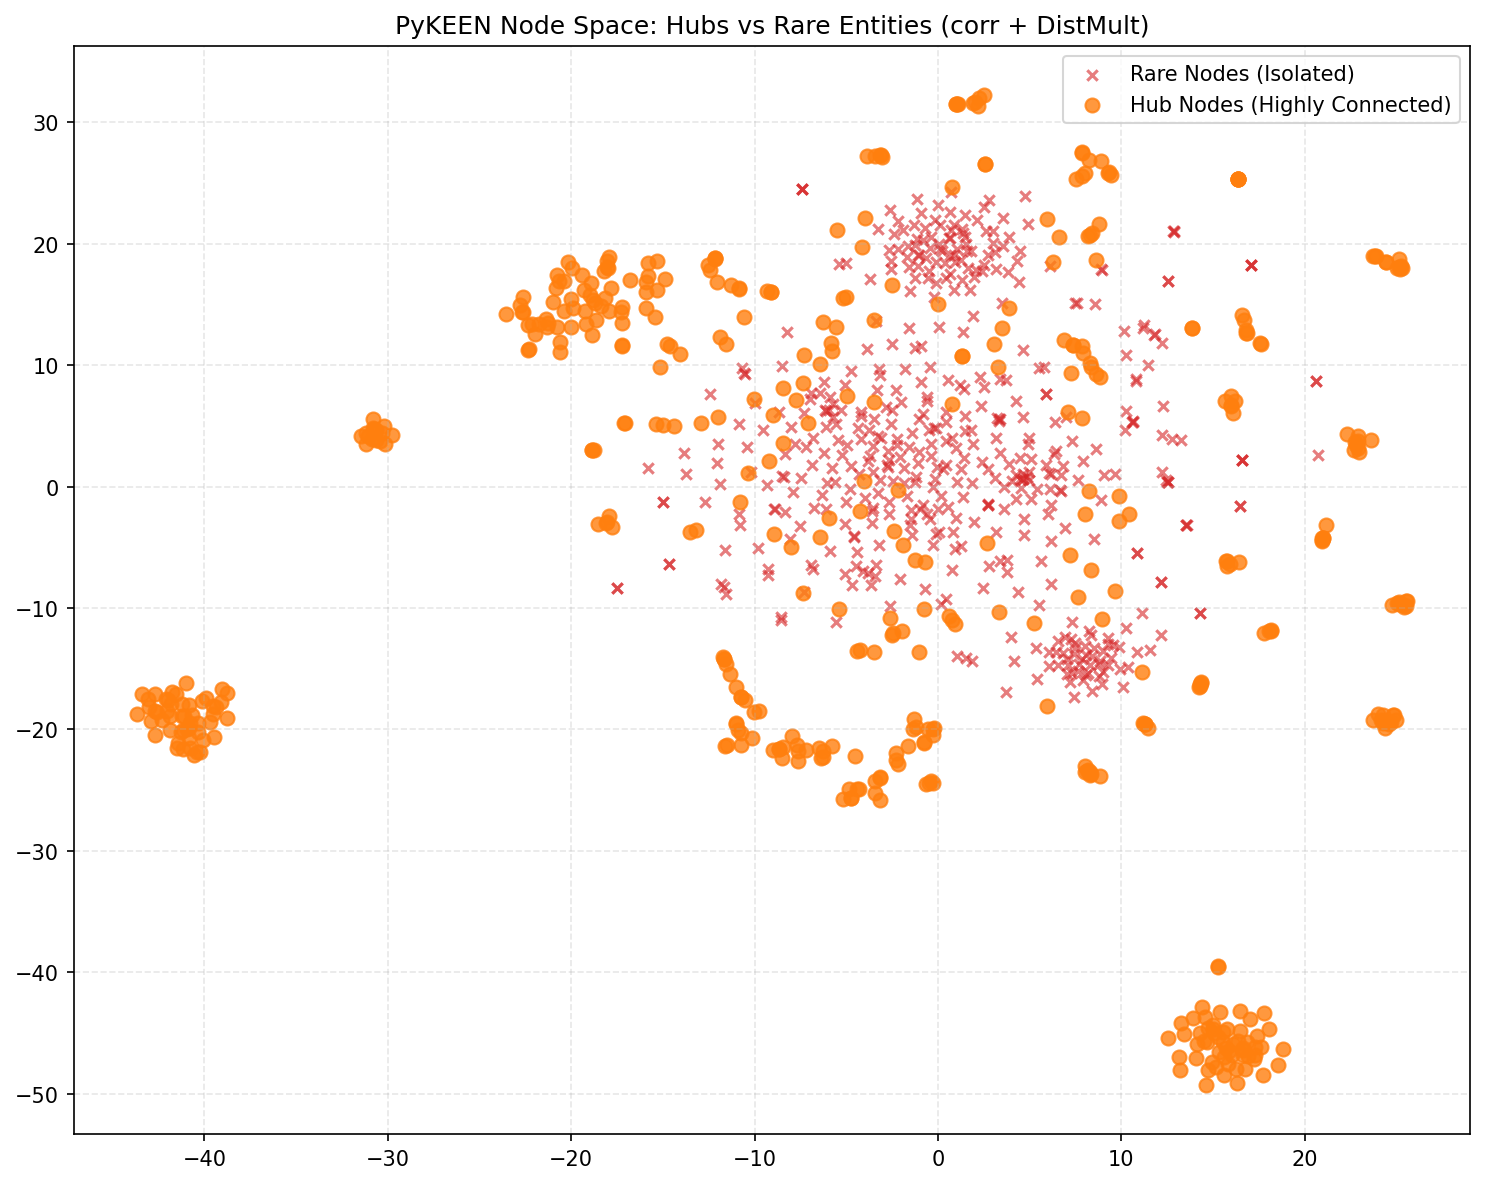

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

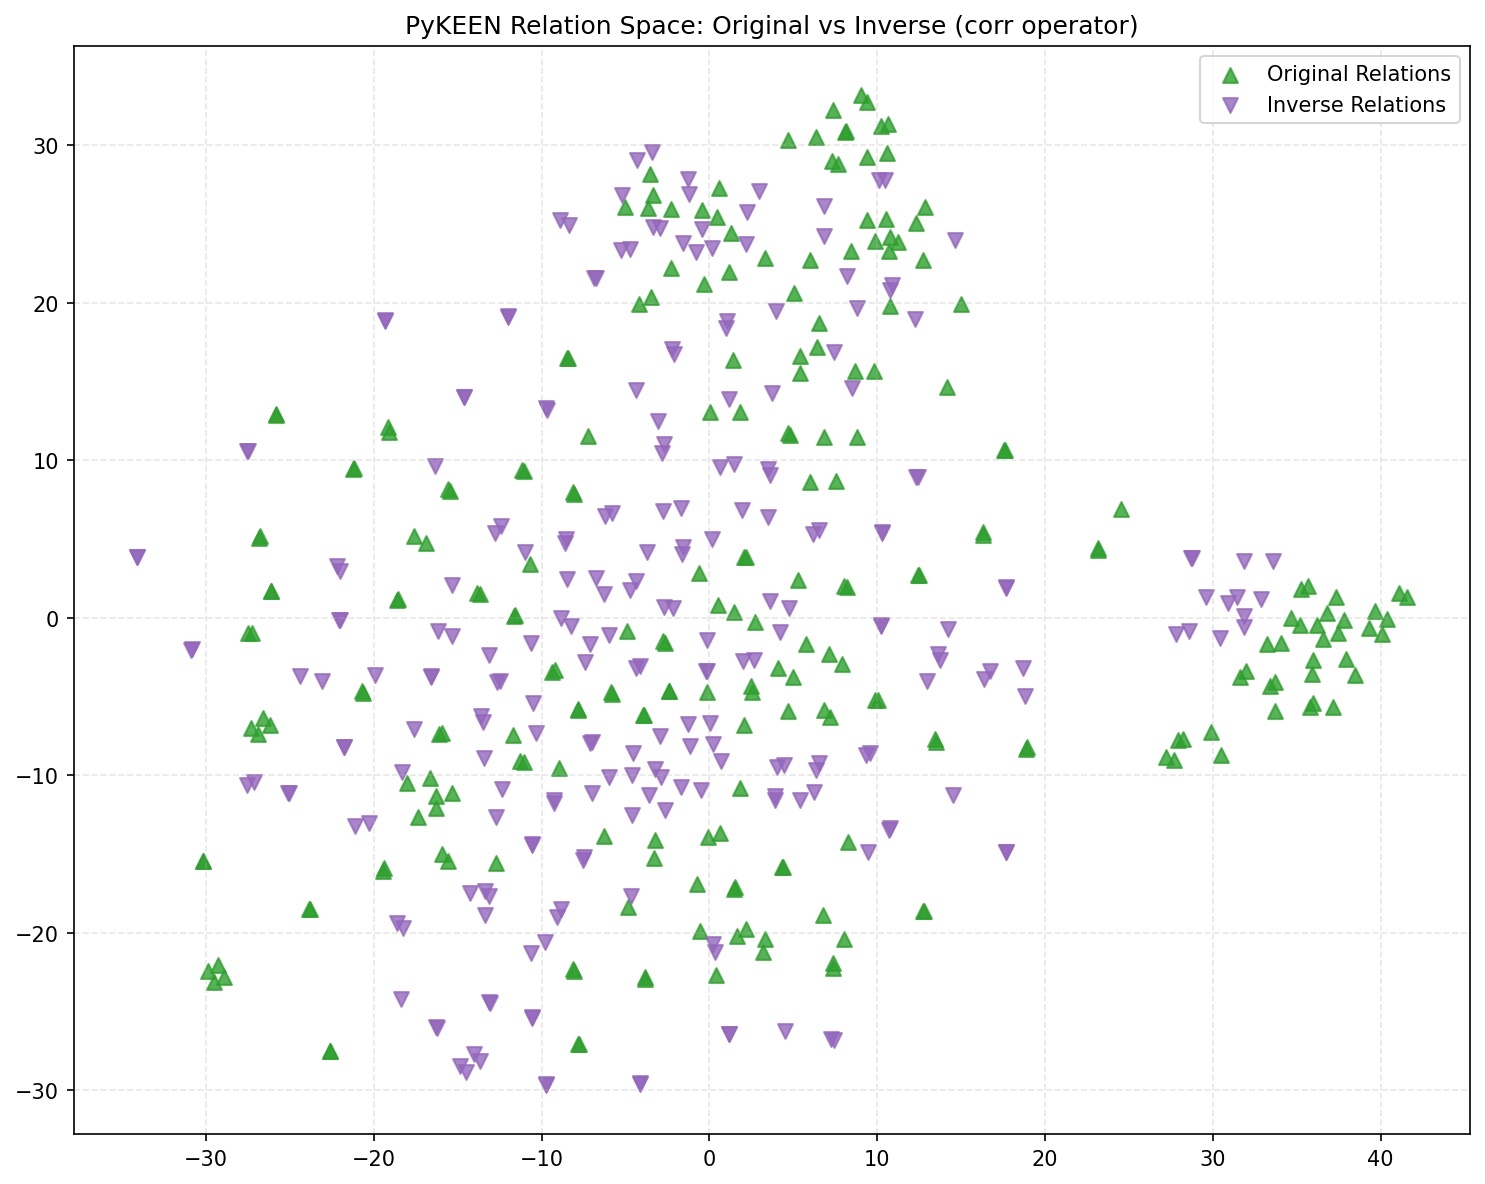

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from google.colab import files
from pykeen.datasets import FB15k237
from pykeen.models import CompGCN



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


dataset = FB15k237(create_inverse_triples=True)
train_triples = dataset.training.mapped_triples.cpu()

path_pykeen = '/content/drive/MyDrive/pykeen_corr_distmult.pt'
model_pykeen = CompGCN(
    triples_factory=dataset.training,
    embedding_dim=128,
    encoder_kwargs=dict(layer_kwargs=dict(composition='circularcorrelation')),
    interaction='DistMult'
).to(device)

model_pykeen.load_state_dict(torch.load(path_pykeen, map_location=device))
model_pykeen.eval()

with torch.no_grad():
    pk_node_embs = model_pykeen.entity_representations[0]().cpu().numpy()
    pk_rel_embs = model_pykeen.relation_representations[0]().cpu().numpy()


pk_degrees = torch.bincount(train_triples[:, 0], minlength=dataset.training.num_entities) + \
             torch.bincount(train_triples[:, 2], minlength=dataset.training.num_entities)

pk_hub_ids = torch.argsort(pk_degrees, descending=True)[:500].numpy()
pk_rare_ids = torch.argsort(pk_degrees, descending=False)[:500].numpy()

pk_node_embs_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(
    pk_node_embs[np.concatenate([pk_hub_ids, pk_rare_ids])]
)

pk_hubs_2d = pk_node_embs_2d[:500]
pk_rares_2d = pk_node_embs_2d[500:]

plt.figure(figsize=(10, 8), dpi=150)
plt.scatter(pk_rares_2d[:, 0], pk_rares_2d[:, 1], c='#d62728', label='Rare Nodes (Isolated)', alpha=0.6, s=25, marker='x')
plt.scatter(pk_hubs_2d[:, 0], pk_hubs_2d[:, 1], c='#ff7f0e', label='Hub Nodes (Highly Connected)', alpha=0.8, s=45, marker='o')
plt.title('PyKEEN Node Space: Hubs vs Rare Entities (corr + DistMult)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
file_node_pyk = 'pykeen_tsne_nodes.png'
plt.savefig(file_node_pyk)
plt.show()
files.download(file_node_pyk)


pk_rel_embs_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(pk_rel_embs)

pk_num_orig = len(pk_rel_embs) // 2
pk_orig_rels = pk_rel_embs_2d[:pk_num_orig]
pk_inv_rels = pk_rel_embs_2d[pk_num_orig:]

plt.figure(figsize=(10, 8), dpi=150)
plt.scatter(pk_orig_rels[:, 0], pk_orig_rels[:, 1], c='#2ca02c', label='Original Relations', alpha=0.8, s=50, marker='^')
plt.scatter(pk_inv_rels[:, 0], pk_inv_rels[:, 1], c='#9467bd', label='Inverse Relations', alpha=0.8, s=50, marker='v')
plt.title('PyKEEN Relation Space: Original vs Inverse (corr operator)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
file_rel_pyk = 'pykeen_tsne_relations.png'
plt.savefig(file_rel_pyk)
plt.show()
files.download(file_rel_pyk)